In [93]:
#Importing dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

In [94]:
#Opening .csv file 

df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Smartwatch dataset_In progress/preprocessed/preprocessed_typing.csv")
df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_X_max,Accelerometer_X_min,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Y_max,Accelerometer_Y_min,Accelerometer_Z_mean,Accelerometer_Z_std,Accelerometer_Z_max,Accelerometer_Z_min,Gyroscope_X_mean,Gyroscope_X_std,Gyroscope_X_max,Gyroscope_X_min,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Y_max,Gyroscope_Y_min,Gyroscope_Z_mean,Gyroscope_Z_std,Gyroscope_Z_max,Gyroscope_Z_min,task,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-0.665711,-1.863480,-1.385773,1.054774,0.148228,-1.635454,1.169252,0.656312,1.395861,0.062564,-0.716554,0.159633,0.627187,-0.202499,-0.618251,0.566004,1.396370,-0.741200,-3.041104,1.650079,3.319412,-2.718235,0,True,False
1,Healthy,1,-1.440854,1.455673,-0.550948,-1.017312,0.861733,0.812738,0.347888,-0.760231,1.549047,0.644172,1.590979,0.177629,2.052114,0.528431,0.637371,-1.360244,-1.174695,0.473085,1.174377,-1.094204,2.632523,1.352064,2.244634,-3.044714,0,False,True
2,Healthy,1,-0.057320,0.000288,0.690811,0.169827,-0.335774,0.253703,0.579272,-2.261057,0.395933,-0.074848,0.551795,-0.161616,-0.073305,0.889236,0.919788,-3.575498,0.107111,0.138340,0.289135,-1.127973,0.040293,0.002580,0.325232,-0.005535,1,True,False
3,Healthy,1,-0.417996,1.176585,0.510503,-0.917322,0.049310,1.215156,1.426583,-0.595149,1.588708,1.065700,1.887318,-0.363768,0.111557,2.846592,3.553490,-5.288271,-0.655967,1.078296,1.621335,-2.977478,0.145056,0.979674,2.271598,-2.037911,1,False,True
4,Healthy,1,0.040363,-0.561332,-0.419716,0.227308,-0.140380,-0.571669,-0.498113,0.532107,-0.154085,-0.396890,-0.480667,0.360544,0.036903,-0.610176,-0.588930,0.681017,0.042508,-0.655203,-0.735737,0.740464,-0.004524,-0.626584,-0.677071,0.557575,2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,Parkinson's,469,0.079142,-0.703760,-0.677144,0.259101,-0.195320,-0.659775,-0.530905,0.619259,-0.130431,-0.661809,-0.807646,0.508550,0.073211,-0.633166,-0.639992,0.682238,0.005614,-0.725237,-0.857704,0.631301,-0.014677,-0.663613,-0.690555,0.764921,8,False,True
7806,Parkinson's,469,2.342317,1.199528,0.662420,-0.344564,0.929031,1.174975,0.217254,-1.192022,0.277188,0.489351,0.433673,-0.331695,1.557720,0.611903,0.811387,-0.007286,0.522475,0.586592,0.667336,-0.309455,-1.552354,2.566972,2.020893,-2.391790,9,True,False
7807,Parkinson's,469,-2.303851,0.605052,-0.199139,-0.356784,1.537547,0.760961,0.144158,-0.223516,-0.013051,0.573294,0.655263,-0.475635,-0.099431,0.461281,0.367459,-0.238936,0.171015,1.020072,1.064460,-0.964653,1.046335,2.113490,1.600687,-1.774930,9,False,True
7808,Parkinson's,469,0.275406,0.242516,-0.098475,-0.068806,-0.315676,1.319913,0.197179,-0.352881,-0.160955,0.380944,0.305811,-0.092746,-1.920761,2.681680,2.244128,-1.712745,1.489368,0.965524,0.945067,-0.494665,-2.540505,2.227508,1.843224,-1.802734,10,True,False


In [95]:
#Checking nulls and label
print(df["condition"].value_counts())

print(df.isnull().sum())

condition
Parkinson's    6072
Healthy        1738
Name: count, dtype: int64
condition               0
patient_id              0
Accelerometer_X_mean    0
Accelerometer_X_std     0
Accelerometer_X_max     0
Accelerometer_X_min     0
Accelerometer_Y_mean    0
Accelerometer_Y_std     0
Accelerometer_Y_max     0
Accelerometer_Y_min     0
Accelerometer_Z_mean    0
Accelerometer_Z_std     0
Accelerometer_Z_max     0
Accelerometer_Z_min     0
Gyroscope_X_mean        0
Gyroscope_X_std         0
Gyroscope_X_max         0
Gyroscope_X_min         0
Gyroscope_Y_mean        0
Gyroscope_Y_std         0
Gyroscope_Y_max         0
Gyroscope_Y_min         0
Gyroscope_Z_mean        0
Gyroscope_Z_std         0
Gyroscope_Z_max         0
Gyroscope_Z_min         0
task                    0
wrist_LeftWrist         0
wrist_RightWrist        0
dtype: int64


In [96]:
#Dropping min and max because they might not be preidctive of the modelm
for col in df.columns:
    if col.endswith("max") or col.endswith("min"):
        df = df.drop(columns = [col])

df

,condition,patient_id,Accelerometer_X_mean,Accelerometer_X_std,Accelerometer_Y_mean,Accelerometer_Y_std,Accelerometer_Z_mean,Accelerometer_Z_std,Gyroscope_X_mean,Gyroscope_X_std,Gyroscope_Y_mean,Gyroscope_Y_std,Gyroscope_Z_mean,Gyroscope_Z_std,task,wrist_LeftWrist,wrist_RightWrist
0,Healthy,1,-1.956550,2.215966,-1.385773,1.054774,1.169252,0.656312,-0.716554,0.159633,-0.618251,0.566004,-3.041104,1.650079,0,True,False
1,Healthy,1,-1.440854,1.455673,0.861733,0.812738,1.549047,0.644172,2.052114,0.528431,-1.174695,0.473085,2.632523,1.352064,0,False,True
2,Healthy,1,-0.057320,0.000288,-0.335774,0.253703,0.395933,-0.074848,-0.073305,0.889236,0.107111,0.138340,0.040293,0.002580,1,True,False
3,Healthy,1,-0.417996,1.176585,0.049310,1.215156,1.588708,1.065700,0.111557,2.846592,-0.655967,1.078296,0.145056,0.979674,1,False,True
4,Healthy,1,0.040363,-0.561332,-0.140380,-0.571669,-0.154085,-0.396890,0.036903,-0.610176,0.042508,-0.655203,-0.004524,-0.626584,2,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7805,Parkinson's,469,0.079142,-0.703760,-0.195320,-0.659775,-0.130431,-0.661809,0.073211,-0.633166,0.005614,-0.725237,-0.014677,-0.663613,8,False,True
7806,Parkinson's,469,2.342317,1.199528,0.929031,1.174975,0.277188,0.489351,1.557720,0.611903,0.522475,0.586592,-1.552354,2.566972,9,True,False
7807,Parkinson's,469,-2.303851,0.605052,1.537547,0.760961,-0.013051,0.573294,-0.099431,0.461281,0.171015,1.020072,1.046335,2.113490,9,False,True
7808,Parkinson's,469,0.275406,0.242516,-0.315676,1.319913,-0.160955,0.380944,-1.920761,2.681680,1.489368,0.965524,-2.540505,2.227508,10,True,False


In [ ]:
#Balancing the class label with smote

#Defining features and labels 
y = df["condition"]
X = df.drop(columns = ["condition", "patient_id", "wrist_LeftWrist", "wrist_RightWrist"])
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Original class distribution:", Counter(y))

smote= SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled class distribution:", Counter(y_resampled))
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)


Original class distribution: Counter({"Parkinson's": 6072, 'Healthy': 1738})
Resampled class distribution: Counter({'Healthy': 6072, "Parkinson's": 6072})


/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [111]:
#Training a RF with no hyperparamter
rfc = RandomForestClassifier()

#Fitting and training
rfc.fit(X_train, y_train)
pred = rfc.predict(X_test)

In [112]:
#Eval metrics
print(accuracy_score(y_test, pred))

print(confusion_matrix(y_test, pred))\

print(classification_report(y_test, pred))

0.8303828736105393
[[1042  164]
 [ 248  975]]
              precision    recall  f1-score   support

     Healthy       0.81      0.86      0.83      1206
 Parkinson's       0.86      0.80      0.83      1223

    accuracy                           0.83      2429
   macro avg       0.83      0.83      0.83      2429
weighted avg       0.83      0.83      0.83      2429



In [113]:
#Tuning hyperparamtyers with GridSearCV
from sklearn.model_selection import GridSearchCV, KFold 

k = KFold(n_splits = 5)

param_rfc = {"n_estimators": [50, 100], "max_depth": [4, 8, 12], "min_samples_split": [4, 6], "min_samples_leaf": [2, 4, 6]}

grid_rfc = GridSearchCV(estimator = rfc, cv = k, param_grid=param_rfc)

In [114]:
#Fitting and training the model
grid_rfc.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(),
             param_grid={'max_depth': [4, 8, 12], 'min_samples_leaf': [2, 4, 6],
                         'min_samples_split': [4, 6],
                         'n_estimators': [50, 100]})

In [115]:
best_params = grid_rfc.best_params_

print(grid_rfc.best_score_)

0.7526505404014412


In [116]:
#Retrainig model based on performance
rfc_model = RandomForestClassifier(n_estimators = best_params["n_estimators"], max_depth = best_params["max_depth"], min_samples_split = best_params["min_samples_split"], min_samples_leaf = best_params["min_samples_leaf"])

In [117]:
#Fitting and training 
rfc_model.fit(X_train, y_train)
pred_rfc = rfc_model.predict(X_test)

In [118]:
#Eval metrics
print(accuracy_score(y_test, pred_rfc))

print(confusion_matrix(y_test, pred_rfc))

print(classification_report(y_test, pred_rfc))

0.760806916426513
[[948 258]
 [323 900]]
              precision    recall  f1-score   support

     Healthy       0.75      0.79      0.77      1206
 Parkinson's       0.78      0.74      0.76      1223

    accuracy                           0.76      2429
   macro avg       0.76      0.76      0.76      2429
weighted avg       0.76      0.76      0.76      2429



In [119]:
#Proceeding with feature selection
model_features = rfc_model.feature_importances_


In [120]:
#Creating a new df with the import features and training on the model
pd_features = pd.DataFrame({"Features": X_train.columns, "Feature_importance": model_features}).sort_values(by = "Feature_importance", ascending = False)
pd_features


,Features,Feature_importance
9,Gyroscope_Y_std,0.094935
7,Gyroscope_X_std,0.091063
3,Accelerometer_Y_std,0.090966
1,Accelerometer_X_std,0.089299
6,Gyroscope_X_mean,0.088264
2,Accelerometer_Y_mean,0.087130
11,Gyroscope_Z_std,0.084619
5,Accelerometer_Z_std,0.081505
8,Gyroscope_Y_mean,0.076792
4,Accelerometer_Z_mean,0.076101


/tmp/ipykernel_2695808/321612773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


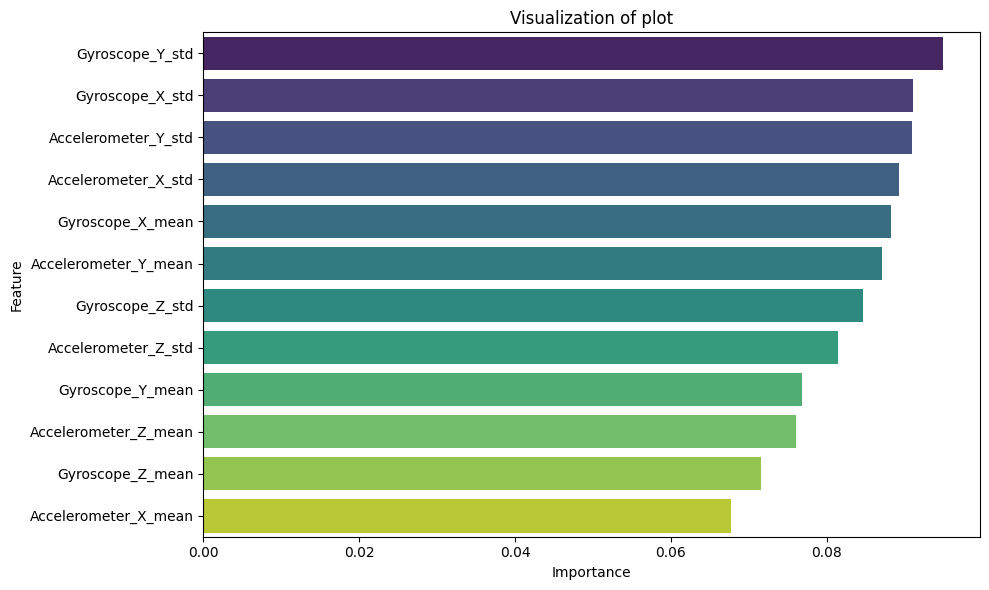

In [121]:
#Visualizations

plt.figure(figsize=(10, 6))
sns.barplot(
    data=pd_features,
    x="Feature_importance",
    y="Features",
    palette="viridis"
)
plt.title("Visualization of plot")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()